# Notebook 01 — Detecção facial

## Objetivo de aprendizado

Entender a **primeira etapa** de qualquer pipeline de reconhecimento facial: **detecção**.

> **Detecção** ≠ **Reconhecimento**.
>
> - **Detecção** responde: *"Tem rosto na imagem? Onde?"* — devolve uma caixa.
> - **Reconhecimento** responde: *"De quem é esse rosto?"* — vem nos notebooks 03+.

Sem detecção, não há o que reconhecer. Se o detector falha, o resto do pipeline morre.

## O que você vai fazer

1. Rodar dois detectores diferentes — **HOG** (rápido) e **CNN** (robusto) — nas suas próprias fotos do dataset.
2. Ver, com seus olhos, quais fotos cada um acerta e quais erra.
3. Aprender **por que** detectores falham, e o que isso significa pro nosso sistema de presença.

## Conceitos novos que vão aparecer

- **HOG (Histogram of Oriented Gradients)**: descritor clássico de visão computacional. Olha pra "direções dos gradientes" (mudanças de intensidade) em janelas da imagem. Rápido, CPU-friendly, mas falha em ângulos.
- **CNN (Convolutional Neural Network)**: rede neural convolucional. Aprende sozinha que padrões representam um rosto, a partir de milhões de exemplos. Mais robusta, mas lenta na CPU.
- **Bounding box**: as 4 coordenadas (`top, right, bottom, left`) que delimitam o rosto na imagem.


## 1. Imports e setup

In [1]:
import time
from pathlib import Path

import face_recognition
import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = Path('../dataset/diogo')
assert DATASET_DIR.exists(), f'Não achei {DATASET_DIR}. Confira a estrutura do projeto.'

fotos = sorted(DATASET_DIR.glob('*.jp*g')) + sorted(DATASET_DIR.glob('*.png'))
print(f'Encontrei {len(fotos)} fotos em {DATASET_DIR}:')
for f in fotos:
    print(f'  - {f.name}')

/home/diogo/Coding/AILAB-FACIAL/.venv/lib/python3.13/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Encontrei 8 fotos em ../dataset/diogo:
  - WhatsApp Image 2026-06-09 at 10.59.30.jpeg
  - WhatsApp Image 2026-06-09 at 10.59.31 (1).jpeg
  - WhatsApp Image 2026-06-09 at 10.59.31 (2).jpeg
  - WhatsApp Image 2026-06-09 at 10.59.31.jpeg
  - WhatsApp Image 2026-06-09 at 10.59.32 (1).jpeg
  - WhatsApp Image 2026-06-09 at 10.59.32 (2).jpeg
  - WhatsApp Image 2026-06-09 at 10.59.32 (3).jpeg
  - WhatsApp Image 2026-06-09 at 10.59.32.jpeg


## 2. Detecção com HOG (o método rápido)

**HOG** é o detector default do `face_recognition`. Funciona assim, em alto nível:

1. Divide a imagem em janelas pequenas (ex.: 16×16 pixels).
2. Em cada janela, calcula a *direção* das bordas (gradientes).
3. Compara o histograma dessas direções com um modelo aprendido de "o que parece um rosto frontal".

**Pontos fortes:** roda em CPU, ~50-100 ms por imagem.

**Pontos fracos:** assume rosto **frontal**. Rosto inclinado, em perfil, ou pequeno demais → falha silenciosa (não detecta nada).

Vamos rodar em todas as suas fotos e medir o tempo.

In [2]:
def detectar(caminho, model='hog'):
    """Detecta rostos numa foto e devolve (imagem, tempo, bounding_boxes)."""
    img = face_recognition.load_image_file(caminho)
    t0 = time.perf_counter()
    boxes = face_recognition.face_locations(img, model=model)
    dt = time.perf_counter() - t0
    return img, dt, boxes

resultados_hog = []
for f in fotos:
    img, dt, boxes = detectar(f, model='hog')
    resultados_hog.append((f, img, dt, boxes))
    status = '✓' if boxes else '✗ NÃO DETECTOU'
    print(f'{f.name:50s}  {dt*1000:6.1f} ms  {len(boxes)} rosto(s)  {status}')

acertos_hog = sum(1 for _,_,_,b in resultados_hog if b)
print(f'\nResumo HOG: {acertos_hog}/{len(fotos)} fotos detectadas.')

WhatsApp Image 2026-06-09 at 10.59.30.jpeg           414.9 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.31 (1).jpeg       433.3 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.31 (2).jpeg       416.1 ms  0 rosto(s)  ✗ NÃO DETECTOU
WhatsApp Image 2026-06-09 at 10.59.31.jpeg           378.2 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.32 (1).jpeg       375.1 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.32 (2).jpeg       379.4 ms  0 rosto(s)  ✗ NÃO DETECTOU
WhatsApp Image 2026-06-09 at 10.59.32 (3).jpeg       369.7 ms  0 rosto(s)  ✗ NÃO DETECTOU
WhatsApp Image 2026-06-09 at 10.59.32.jpeg           368.7 ms  1 rosto(s)  ✓

Resumo HOG: 5/8 fotos detectadas.


### 🔎 Pause e observe

Provavelmente algumas fotos **não** detectaram. Isso **não é bug** — é a realidade do HOG. Vamos visualizar pra entender.

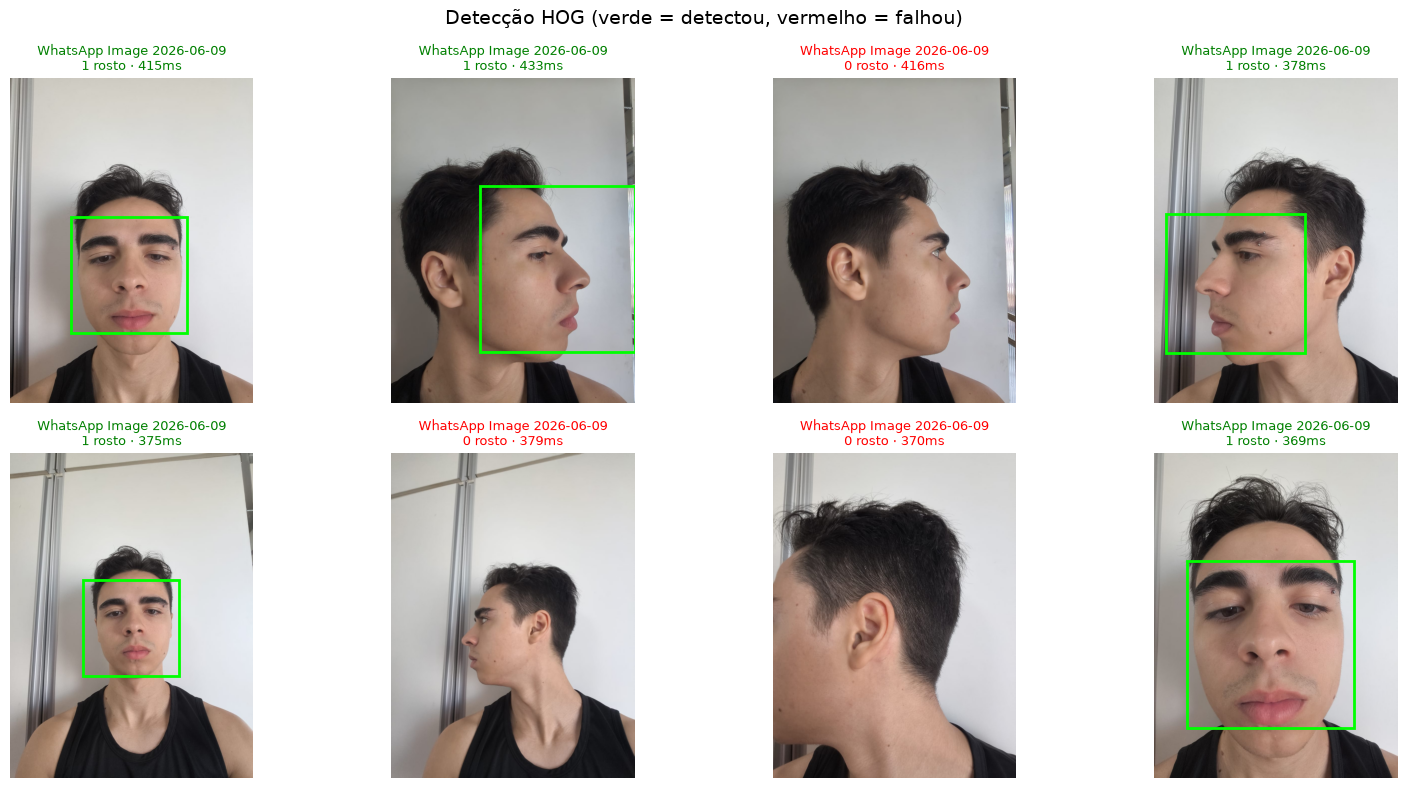

In [3]:
def plot_resultado(resultados, titulo):
    n = len(resultados)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    for ax, (f, img, dt, boxes) in zip(axes, resultados):
        ax.imshow(img)
        ax.set_title(f'{f.name[:25]}\n{len(boxes)} rosto · {dt*1000:.0f}ms',
                     color='green' if boxes else 'red', fontsize=9)
        for (top, right, bottom, left) in boxes:
            ax.add_patch(plt.Rectangle((left, top), right-left, bottom-top,
                                       fill=False, color='lime', linewidth=2))
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_resultado(resultados_hog, 'Detecção HOG (verde = detectou, vermelho = falhou)')

## 3. Detecção com CNN (o método robusto)

**CNN** usa uma rede neural convolucional pré-treinada (o `face_recognition` usa um modelo do dlib treinado em milhares de rostos com várias poses).

**Pontos fortes:** detecta rostos inclinados, parcialmente ocluídos, em iluminação ruim.

**Pontos fracos:** **muito** mais lenta em CPU — pode levar 1-5 segundos por imagem sem GPU.

> ⏱️ Esta célula vai demorar — talvez 1 minuto para 5-8 fotos. **É normal.** É o preço de não ter GPU.

In [4]:
resultados_cnn = []
for f in fotos:
    img, dt, boxes = detectar(f, model='cnn')
    resultados_cnn.append((f, img, dt, boxes))
    status = '✓' if boxes else '✗'
    print(f'{f.name:50s}  {dt*1000:7.0f} ms  {len(boxes)} rosto(s)  {status}')

acertos_cnn = sum(1 for _,_,_,b in resultados_cnn if b)
print(f'\nResumo CNN: {acertos_cnn}/{len(fotos)} fotos detectadas.')

WhatsApp Image 2026-06-09 at 10.59.30.jpeg            32548 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.31 (1).jpeg        29962 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.31 (2).jpeg        29921 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.31.jpeg            29983 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.32 (1).jpeg        30230 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.32 (2).jpeg        32782 ms  1 rosto(s)  ✓
WhatsApp Image 2026-06-09 at 10.59.32 (3).jpeg        29861 ms  0 rosto(s)  ✗
WhatsApp Image 2026-06-09 at 10.59.32.jpeg            30063 ms  1 rosto(s)  ✓

Resumo CNN: 7/8 fotos detectadas.


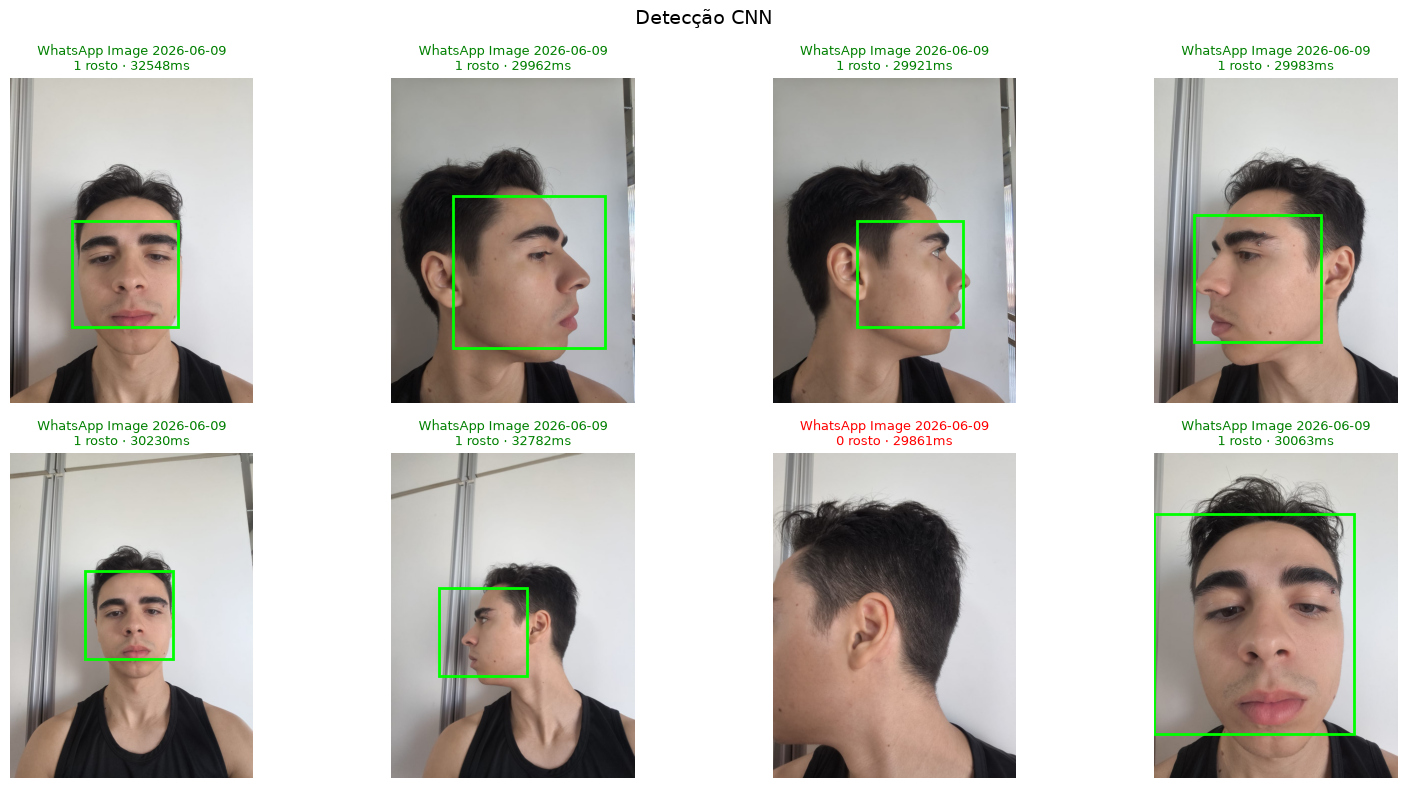

In [5]:
plot_resultado(resultados_cnn, 'Detecção CNN')

## 4. Comparação lado a lado

Vamos consolidar tudo numa tabela.

In [6]:
import pandas as pd

linhas = []
for (f, _, dt_hog, b_hog), (_, _, dt_cnn, b_cnn) in zip(resultados_hog, resultados_cnn):
    linhas.append({
        'foto': f.name[:35],
        'HOG_ms': round(dt_hog*1000, 1),
        'HOG_rostos': len(b_hog),
        'CNN_ms': round(dt_cnn*1000, 0),
        'CNN_rostos': len(b_cnn),
        'speedup_CNN/HOG': f'{dt_cnn/dt_hog:.0f}x',
    })
df = pd.DataFrame(linhas)
df

,foto,HOG_ms,HOG_rostos,CNN_ms,CNN_rostos,speedup_CNN/HOG
0,WhatsApp Image 2026-06-09 at 10.59.,414.9,1,32548.0,1,78x
1,WhatsApp Image 2026-06-09 at 10.59.,433.3,1,29962.0,1,69x
2,WhatsApp Image 2026-06-09 at 10.59.,416.1,0,29921.0,1,72x
3,WhatsApp Image 2026-06-09 at 10.59.,378.2,1,29983.0,1,79x
4,WhatsApp Image 2026-06-09 at 10.59.,375.1,1,30230.0,1,81x
5,WhatsApp Image 2026-06-09 at 10.59.,379.4,0,32782.0,1,86x
6,WhatsApp Image 2026-06-09 at 10.59.,369.7,0,29861.0,0,81x
7,WhatsApp Image 2026-06-09 at 10.59.,368.7,1,30063.0,1,82x


## 5. Análise das falhas — *por que* o HOG erra?

Olha as fotos onde HOG falhou e CNN acertou. Tipicamente, as falhas seguem padrões:

| Padrão | Por que o HOG erra |
|---|---|
| Rosto **inclinado** > 30° | HOG aprende padrão de rosto frontal; perfil muda toda a distribuição de gradientes |
| Rosto **muito pequeno** (< 80px) | Pouca informação de gradiente, ruído domina |
| **Backlight** (luz forte atrás) | Rosto fica escuro, perde detalhe de borda |
| **Óculos escuros** | Apagam a região mais informativa (olhos) |
| Foto **borrada** | Sem gradiente nítido → sem feature |

### Para você anotar

Crie `notebooks/duvidas.md` e responda:

1. Quantas das suas fotos o HOG perdeu?
2. O CNN recuperou todas?
3. Olhando as falhas do HOG, qual padrão você reconhece?

## 6. O que isso significa pro sistema de presença

**Decisão de engenharia que isso destrava:**

- **Cadastro (uma vez por pessoa, sem pressa)** → podemos usar **CNN**. Tempo de 2s não importa, e queremos máxima qualidade dos embeddings de referência. Vamos garantir, no Sprint 2, que `enroll.py` use CNN.
- **Reconhecimento ao vivo no tablet (precisa de ~2 fps)** → vamos usar o **detector rápido** equivalente do face-api.js (`TinyFaceDetector`), que é o análogo JS do HOG. O tablet S6 Lite tem CPU fraca, não aguenta CNN em tempo real.
- **Implicação no cadastro:** as fotos que o operador tirar do participante **precisam ser bem enquadradas e iluminadas**. Se o cadastro tem foto ruim, o operador refaz. Não dá pra confiar no detector "resolver" no tablet — o pipeline de reconhecimento usa o detector rápido, que falha em condições ruins.

## 7. Próximo notebook

`02_landmarks_alignment.ipynb` — depois de achar o rosto, como **alinhamos** ele (rotacionar para os olhos ficarem horizontais)? Por que isso melhora drasticamente o embedding?
